 EDA para o Problema da Minerva

## Import

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [ ]:
# ---------------------------------------------------------
# CONFIGURAÇÃO DO DIRETÓRIO RAIZ
# ---------------------------------------------------------
# Verifica se a pasta 'data' existe no diretório atual. 
# Se não existir, ele assume que estamos na pasta 'notebook' e sobe um nível ('..')
if not os.path.isdir('data'):
    os.chdir('..')

print(f"Diretório de trabalho atualizado para: {os.getcwd()}")

In [ ]:
file_path = 'data/raw/instance_desafio_minerva.xlsx'

## Leitura dos dados

In [ ]:
df = pd.read_excel(file_path, sheet_name='base_dados')

In [ ]:
df.head()

In [ ]:
display(df.info())

In [ ]:
# 1. Garantir que a Data é do tipo datetime
df['Data'] = pd.to_datetime(df['Data'])

# 2. Extrair o Dia da Semana e mapear para nomes
dias_map = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 
            4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['Dia da Semana'] = df['Data'].dt.dayofweek.map(dias_map)

# 3. Calcular Variáveis Unitárias
df['Preço'] = df['Receita Realizada (R$)'] / df['Volume Realizado (kg)']
df['Custo Realizado (R$/kg)'] = df['Custo Realizado (R$)'] / df['Volume Realizado (kg)']

# Visualização inicial para confirmar
display(df.head())

## Separar em teste e treino
- Definido por regra que o treino é até dia 31/10/2025 (inclusive)

In [ ]:
data_corte = pd.to_datetime('2025-10-31')

# Treino: Dados até 31/10/2025 (inclusive)
df_treino = df[df['Data'] <= data_corte].copy()

# Teste: Dados a partir de 01/11/2025
df_teste = df[df['Data'] > data_corte].copy()

print(f"Período de Treino: {df_treino['Data'].min().date()} até {df_treino['Data'].max().date()}")
print(f"Período de Teste: {df_teste['Data'].min().date()} até {df_teste['Data'].max().date()}\n")

print(f"Tamanho da base de Treino: {df_treino.shape[0]} dias")
print(f"Tamanho da base de Teste: {df_teste.shape[0]} dias")

## Estatística Descritiva (Treino)

In [ ]:
# Cálculo da Margem (Receita - Custo)
df_treino['Margem'] = df_treino['Receita Realizada (R$)'] - df_treino['Custo Realizado (R$)']

# Seleção das colunas numéricas de interesse
cols_analise = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem']

# Geração da tabela descritiva (transposta para melhor visualização)
descritiva = df_treino[cols_analise].describe().T
descritiva['Coef_Variacao (%)'] = (descritiva['std'] / descritiva['mean']) * 100

print("Estatística Descritiva (Base de Treino Oficial - Até 31/10/2025):")
display(descritiva.round(2))

## Outliers

In [ ]:
# Ordenando os dias para o eixo X do gráfico fazer sentido
ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Note que alteramos o x para 'Dia da Semana'
sns.boxplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[0], palette="Blues_d")
axes[0].set_title("Distribuição de Volume por Dia da Semana", fontsize=14)
axes[0].set_xlabel("Dia da Semana")
axes[0].set_ylabel("Volume Diário (kg)")

# Gráfico de Barras: Alterado o x para 'Dia da Semana'
sns.barplot(data=df_treino, x='Dia da Semana', y='Volume Realizado (kg)', 
            order=ordem_dias, ax=axes[1], errorbar=None, palette="Blues_d")
axes[1].set_title("Volume Médio Diário por Dia da Semana", fontsize=14)
axes[1].set_xlabel("Dia da Semana")
axes[1].set_ylabel("Média de Volume (kg)")

plt.tight_layout()
plt.show()

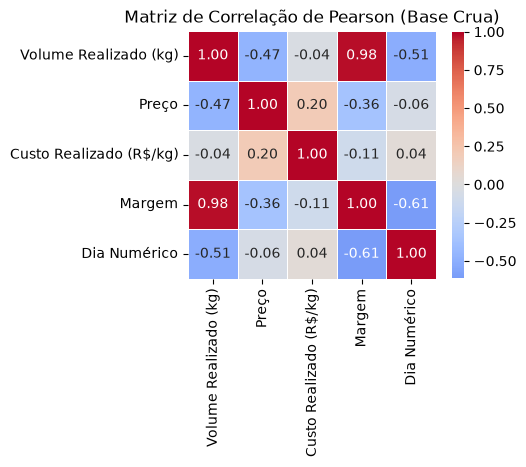

In [27]:
# Criando uma coluna numérica para o dia da semana para usar na correlação
df_treino['Dia Numérico'] = df_treino['Data'].dt.dayofweek

cols_corr = ['Volume Realizado (kg)', 'Preço', 'Custo Realizado (R$/kg)', 'Margem', 'Dia Numérico']
matriz_corr = df_treino[cols_corr].corr()

plt.figure(figsize=(4,4))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de Correlação de Pearson (Base Crua)", fontsize=12)
plt.show()

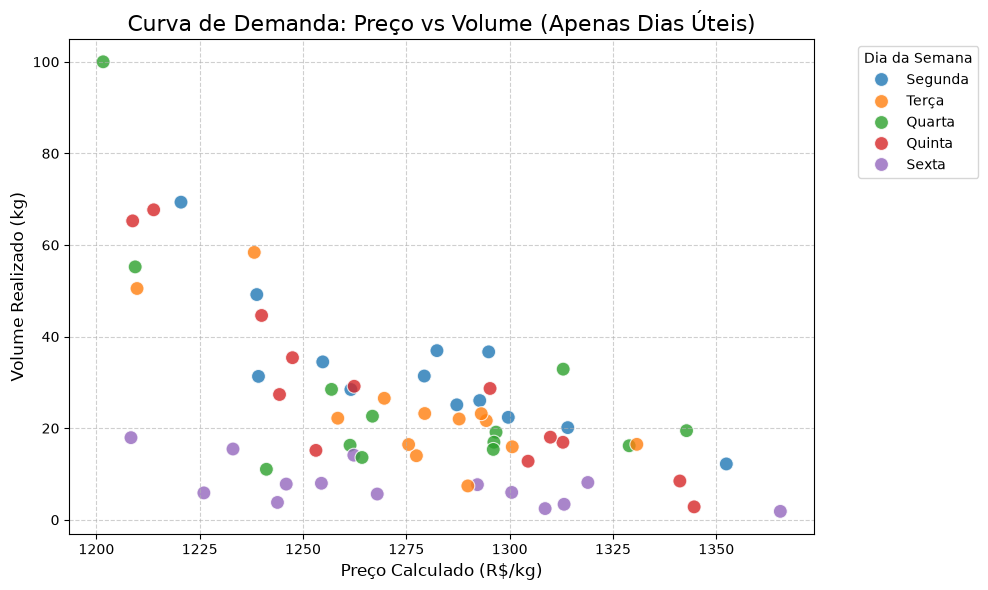

In [28]:
# Isolando apenas os dias úteis (Segunda a Sexta) usando o dia numérico
df_uteis = df_treino[~df_treino['Data'].dt.dayofweek.isin([5, 6])]

plt.figure(figsize=(10, 6))

# Scatterplot: Alteramos o hue para 'Dia da Semana'
sns.scatterplot(data=df_uteis, x='Preço', y='Volume Realizado (kg)', 
                hue='Dia da Semana', hue_order=['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'], 
                palette="tab10", s=100, alpha=0.8)

plt.title("Curva de Demanda: Preço vs Volume (Apenas Dias Úteis)", fontsize=16)
plt.xlabel("Preço Calculado (R$/kg)", fontsize=12)
plt.ylabel("Volume Realizado (kg)", fontsize=12)
plt.legend(title="Dia da Semana", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()